In [5]:
# ============================================================
# CELL 1 — IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import json
import time
import random
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [6]:
# ============================================================
# CELL 2 — LOAD DATA
# ============================================================

df = pd.read_csv('GSPC.csv')

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (24801, 7)

Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

First 5 rows:


,Date,Open,High,Low,Close,Adj Close,Volume
0,1927-12-30,17.660000,17.660000,17.660000,17.660000,17.660000,0
1,1928-01-03,17.760000,17.760000,17.760000,17.760000,17.760000,0
2,1928-01-04,17.719999,17.719999,17.719999,17.719999,17.719999,0
3,1928-01-05,17.549999,17.549999,17.549999,17.549999,17.549999,0
4,1928-01-06,17.660000,17.660000,17.660000,17.660000,17.660000,0


In [7]:
# ============================================================
# CELL 3 — DATE PROCESSING
# ============================================================

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

print(
    f"Date range: "
    f"{df['Date'].min().date()} → "
    f"{df['Date'].max().date()}"
)

print(
    "Chronological:",
    df["Date"].is_monotonic_increasing
)

Date range: 1927-12-30 → 2026-09-25
Chronological: True


In [8]:
# ============================================================
# CELL 4 — BASIC INFORMATION
# ============================================================

print("Dataset shape:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nStatistical summary:")
display(df.describe())

Dataset shape:
(24801, 7)

Data types:
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object

Statistical summary:


,Date,Open,High,Low,Close,Adj Close,Volume
count,24801,24801.000000,24801.000000,24801.000000,24801.000000,24801.000000,2.480100e+04
mean,1977-06-12 23:39:51.145518336,763.057677,767.396948,758.450773,763.218436,763.218436,9.950448e+08
min,1927-12-30 00:00:00,4.400000,4.400000,4.400000,4.400000,4.400000,0.000000e+00
25%,1952-10-27 00:00:00,25.059999,25.059999,25.059999,25.059999,25.059999,1.630000e+06
50%,1977-07-18 00:00:00,103.940002,104.800003,103.129997,103.940002,103.940002,2.323000e+07
75%,2002-02-04 00:00:00,1102.589966,1109.239990,1094.630005,1102.829956,1102.829956,1.238000e+09
max,2026-09-25 00:00:00,7806.600098,7816.700195,7776.310059,7798.990234,7798.990234,1.145623e+10
std,NaN,1334.735184,1341.640890,1327.355873,1334.990098,1334.990098,1.715115e+09


In [9]:
# ============================================================
# CELL 5 — MISSING VALUES
# ============================================================

missing = df.isnull().sum()

print("Missing values:")
print(missing)

print("\nTotal missing values:", missing.sum())

Missing values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Total missing values: 0


In [10]:
# ============================================================
# CELL 6 — DUPLICATE CHECK
# ============================================================

duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [11]:
# ============================================================
# CELL 7 — OHLC VALIDATION
# ============================================================

invalid_ohlc = df[
    (df["High"] < df["Low"]) |
    (df["High"] < df["Open"]) |
    (df["High"] < df["Close"]) |
    (df["Low"] > df["Open"]) |
    (df["Low"] > df["Close"])
]

print("Invalid OHLC rows:", len(invalid_ohlc))

if len(invalid_ohlc) > 0:
    display(invalid_ohlc.head())
else:
    print("OHLC validation passed.")

Invalid OHLC rows: 0
OHLC validation passed.


In [12]:
# ============================================================
# CELL 8 — VOLUME CHECK
# ============================================================

zero_volume = df[df["Volume"] == 0]

print("Zero-volume rows:", len(zero_volume))

if len(zero_volume) > 0:
    print(
        "Zero-volume period:",
        zero_volume["Date"].min().date(),
        "→",
        zero_volume["Date"].max().date()
    )

print("\nWe will NOT use Volume in the first LSTM model.")

Zero-volume rows: 5497
Zero-volume period: 1927-12-30 → 2023-05-24

We will NOT use Volume in the first LSTM model.


In [13]:
# ============================================================
# CELL 9 — ADJ CLOSE CHECK
# ============================================================

difference = np.abs(
    df["Close"] - df["Adj Close"]
)

print(
    "Maximum Close vs Adj Close difference:",
    difference.max()
)

if difference.max() == 0:
    print("Close and Adj Close are identical.")
else:
    print("Close and Adj Close are different.")

Maximum Close vs Adj Close difference: 0.0
Close and Adj Close are identical.


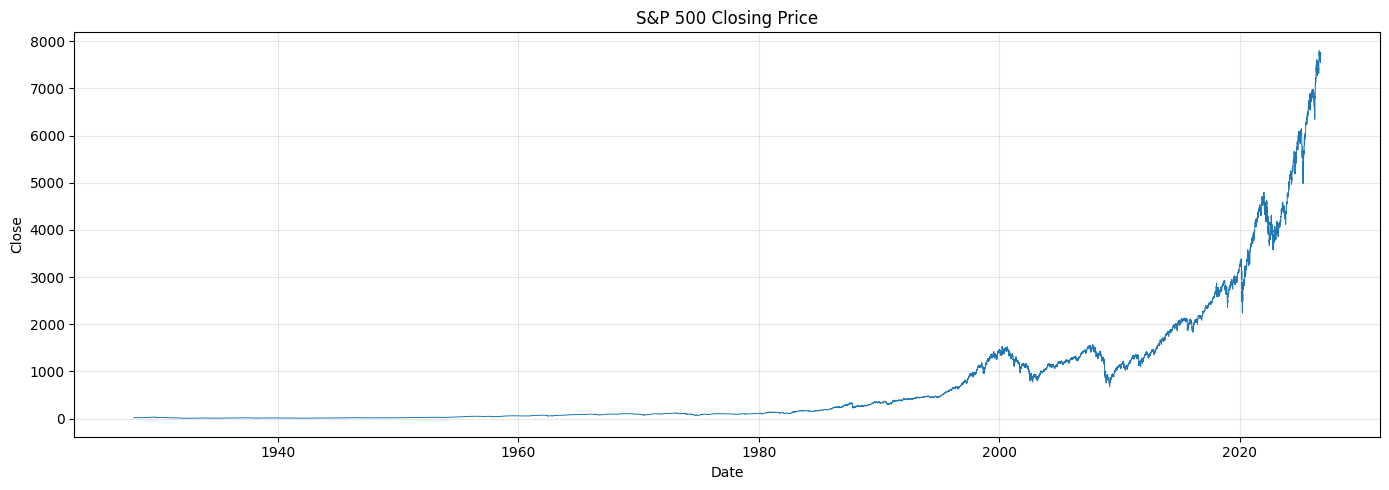

In [14]:
# ============================================================
# CELL 10 — CLOSING PRICE
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    df["Date"],
    df["Close"],
    linewidth=0.7
)

plt.title("S&P 500 Closing Price")
plt.xlabel("Date")
plt.ylabel("Close")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

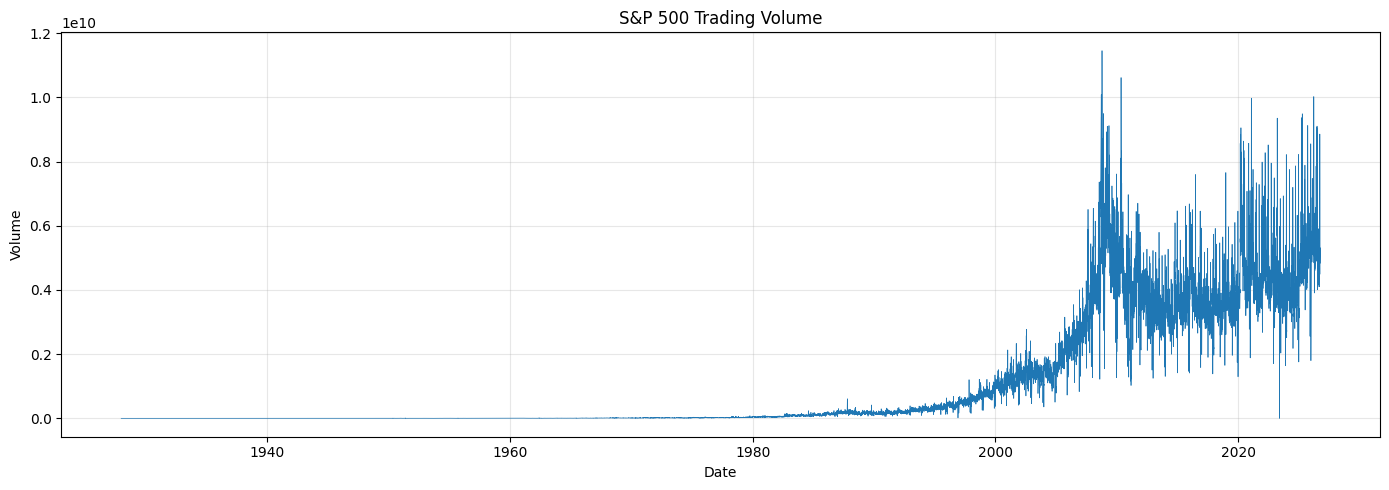

In [15]:
# ============================================================
# CELL 11 — VOLUME
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    df["Date"],
    df["Volume"],
    linewidth=0.5
)

plt.title("S&P 500 Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

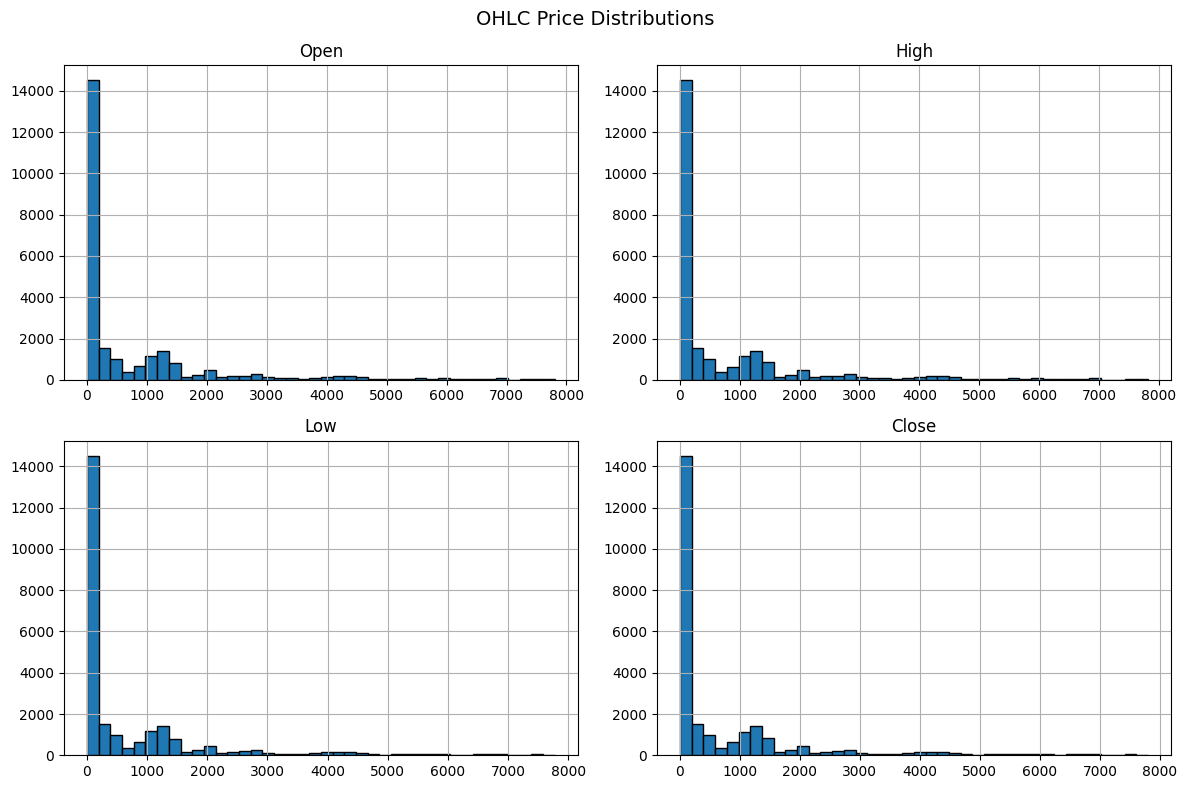

In [16]:
# ============================================================
# CELL 12 — OHLC DISTRIBUTIONS
# ============================================================

df[
    ["Open", "High", "Low", "Close"]
].hist(
    figsize=(12, 8),
    bins=40,
    edgecolor="black"
)

plt.suptitle(
    "OHLC Price Distributions",
    fontsize=14
)

plt.tight_layout()
plt.show()

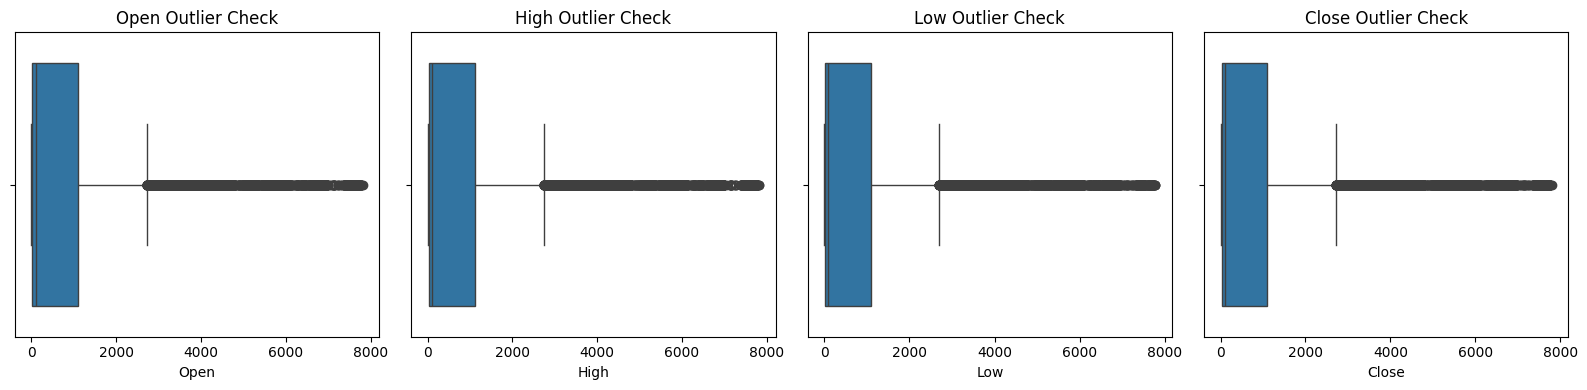

In [17]:
# ============================================================
# CELL 13 — OUTLIER CHECK
# ============================================================

fig, axes = plt.subplots(
    1, 4,
    figsize=(16, 4)
)

for ax, col in zip(
    axes,
    ["Open", "High", "Low", "Close"]
):

    sns.boxplot(
        x=df[col],
        ax=ax
    )

    ax.set_title(
        f"{col} Outlier Check"
    )

plt.tight_layout()
plt.show()

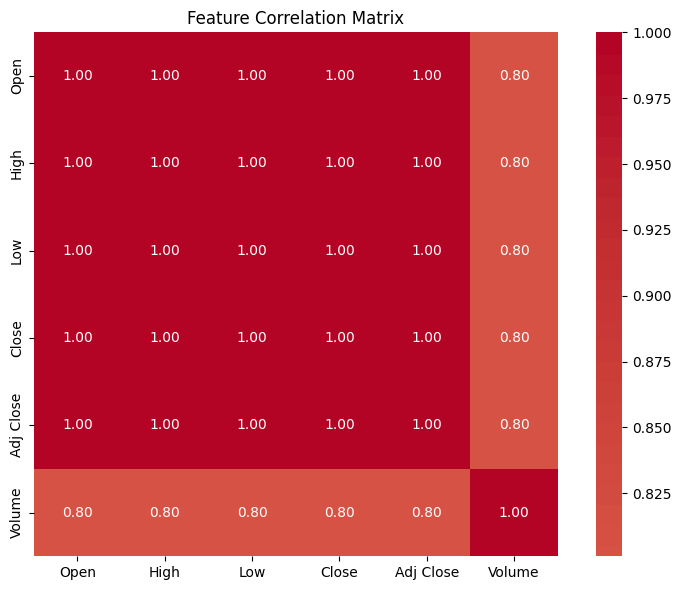

In [18]:
# ============================================================
# CELL 14 — CORRELATION
# ============================================================

correlation = df[
    [
        "Open",
        "High",
        "Low",
        "Close",
        "Adj Close",
        "Volume"
    ]
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# CELL 15 — FEATURE ENGINEERING
# ============================================================

# ------------------------------------------------------------
# Moving averages
# ------------------------------------------------------------

df["MA_7"] = (
    df["Close"]
    .rolling(7)
    .mean()
)

df["MA_20"] = (
    df["Close"]
    .rolling(20)
    .mean()
)


# ------------------------------------------------------------
# 9 stationary features
# ------------------------------------------------------------

df["Daily_Return"] = (
    df["Close"].pct_change()
)

df["Price_Range_Pct"] = (
    (df["High"] - df["Low"])
    / df["Close"]
)

df["Open_Close_Pct"] = (
    (df["Close"] - df["Open"])
    / df["Open"]
)

df["Close_MA7_Ratio"] = (
    df["Close"] / df["MA_7"] - 1
)

df["Close_MA20_Ratio"] = (
    df["Close"] / df["MA_20"] - 1
)

df["Volatility_20"] = (
    df["Daily_Return"]
    .rolling(20)
    .std()
)

df["MA7_MA20_Cross"] = (
    df["MA_7"] / df["MA_20"] - 1
)

df["Momentum_5"] = (
    df["Close"]
    / df["Close"].shift(5)
    - 1
)

df["Momentum_10"] = (
    df["Close"]
    / df["Close"].shift(10)
    - 1
)


FEATURES = [
    "Daily_Return",
    "Price_Range_Pct",
    "Open_Close_Pct",
    "Close_MA7_Ratio",
    "Close_MA20_Ratio",
    "Volatility_20",
    "MA7_MA20_Cross",
    "Momentum_5",
    "Momentum_10"
]

print("Number of features:", len(FEATURES))
print("\nFeatures:")

for i, feature in enumerate(FEATURES, 1):
    print(i, feature)

Number of features: 9

Features:
1 Daily_Return
2 Price_Range_Pct
3 Open_Close_Pct
4 Close_MA7_Ratio
5 Close_MA20_Ratio
6 Volatility_20
7 MA7_MA20_Cross
8 Momentum_5
9 Momentum_10


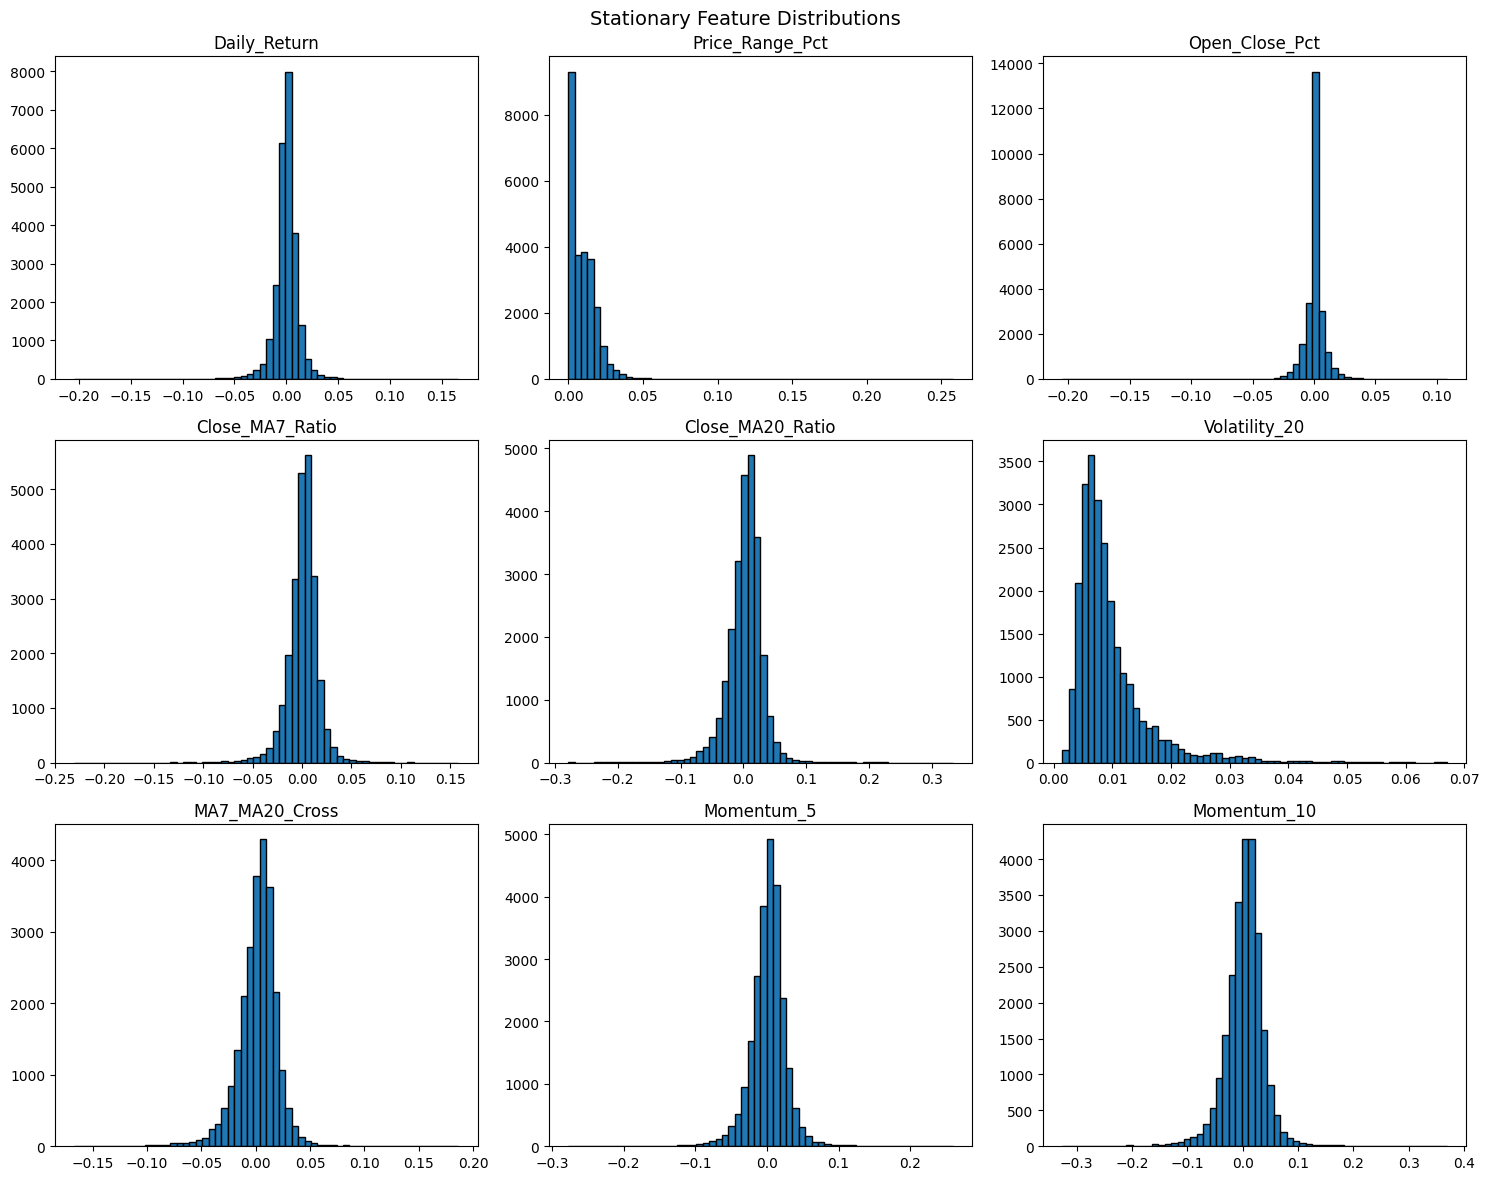

In [20]:
# ============================================================
# CELL 16 — FEATURE DISTRIBUTIONS
# ============================================================

fig, axes = plt.subplots(
    3,
    3,
    figsize=(15, 12)
)

axes = axes.flatten()

for i, feature in enumerate(FEATURES):

    axes[i].hist(
        df[feature].dropna(),
        bins=60,
        edgecolor="black"
    )

    axes[i].set_title(feature)

plt.suptitle(
    "Stationary Feature Distributions",
    fontsize=14
)

plt.tight_layout()
plt.show()

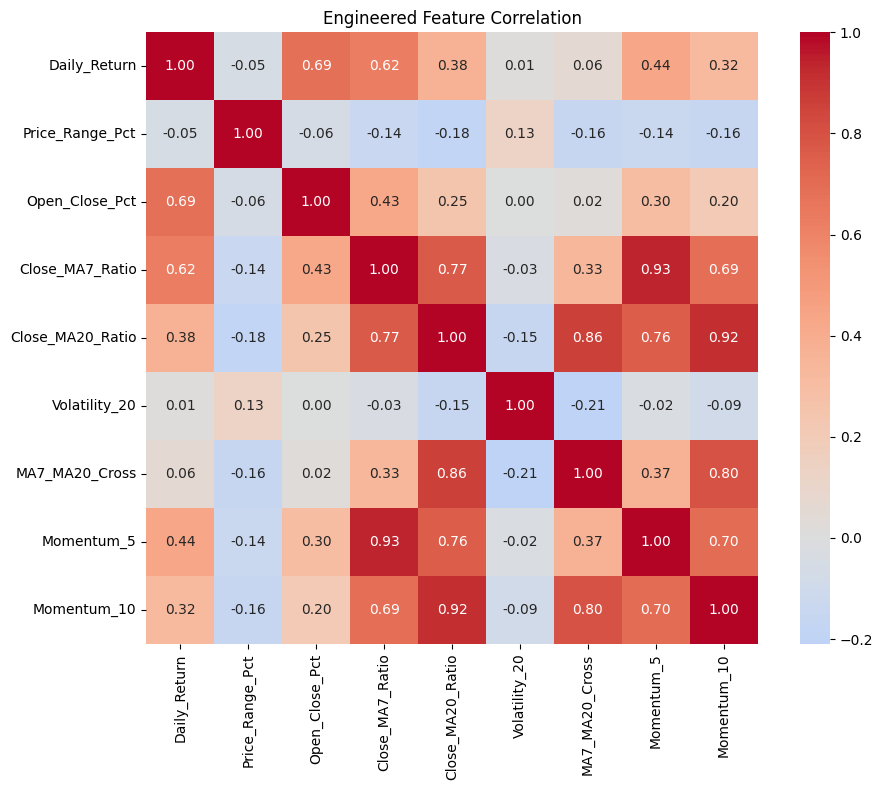

In [21]:
# ============================================================
# CELL 17 — FEATURE CORRELATION
# ============================================================

feature_corr = (
    df[FEATURES]
    .dropna()
    .corr()
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    feature_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title(
    "Engineered Feature Correlation"
)

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# CELL 18 — TARGET
# ============================================================

# Tomorrow's close
df["Next_Close"] = (
    df["Close"].shift(-1)
)

# Tomorrow's return
df["Target"] = (
    (df["Next_Close"] - df["Close"])
    / df["Close"]
)

print(
    df[
        [
            "Date",
            "Close",
            "Next_Close",
            "Target"
        ]
    ].head(10)
)

        Date      Close  Next_Close    Target
0 1927-12-30  17.660000   17.760000  0.005663
1 1928-01-03  17.760000   17.719999 -0.002252
2 1928-01-04  17.719999   17.549999 -0.009594
3 1928-01-05  17.549999   17.660000  0.006268
4 1928-01-06  17.660000   17.500000 -0.009060
5 1928-01-09  17.500000   17.370001 -0.007429
6 1928-01-10  17.370001   17.350000 -0.001151
7 1928-01-11  17.350000   17.469999  0.006916
8 1928-01-12  17.469999   17.580000  0.006297
9 1928-01-13  17.580000   17.290001 -0.016496


In [23]:
# ============================================================
# CELL 19 — CLEAN DATA
# ============================================================

df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

rows_before = len(df)

df = (
    df
    .dropna()
    .reset_index(drop=True)
)

rows_after = len(df)

print("Rows before:", rows_before)
print("Rows after :", rows_after)
print("Rows dropped:", rows_before - rows_after)

print(
    "\nRemaining missing values:",
    df.isnull().sum().sum()
)

Rows before: 24801
Rows after : 24780
Rows dropped: 21

Remaining missing values: 0


In [24]:
# ============================================================
# CELL 20 — TREND CLASSIFICATION
# ============================================================

TREND_THRESHOLD = 0.005   # 0.5%


def classify_trend(
    returns,
    threshold=TREND_THRESHOLD
):

    return np.where(
        returns > threshold,
        "BULLISH",

        np.where(
            returns < -threshold,
            "BEARISH",
            "NEUTRAL"
        )
    )


df["Trend"] = classify_trend(
    df["Target"].values
)

print(
    df["Trend"]
    .value_counts()
)

print("\nPercentage:")

print(
    (
        df["Trend"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

Trend
NEUTRAL    12345
BULLISH     6628
BEARISH     5807
Name: count, dtype: int64

Percentage:
Trend
NEUTRAL    49.82
BULLISH    26.75
BEARISH    23.43
Name: proportion, dtype: float64


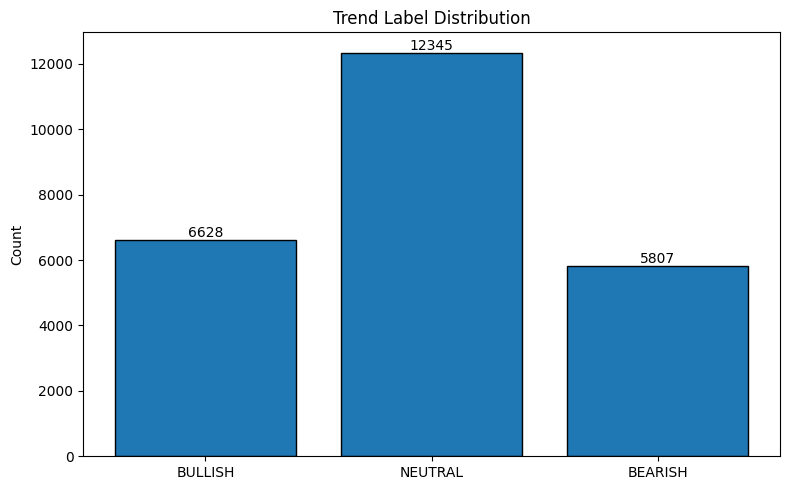

In [25]:
# ============================================================
# CELL 21 — TREND DISTRIBUTION
# ============================================================

counts = (
    df["Trend"]
    .value_counts()
    .reindex(
        ["BULLISH", "NEUTRAL", "BEARISH"],
        fill_value=0
    )
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    counts.index,
    counts.values,
    edgecolor="black"
)

for bar, value in zip(
    bars,
    counts.values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(value),
        ha="center",
        va="bottom"
    )

plt.title(
    "Trend Label Distribution"
)

plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# CELL 22 — CHRONOLOGICAL SPLIT
# ============================================================

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

n = len(df)

train_size = int(
    n * TRAIN_RATIO
)

val_size = int(
    n * VAL_RATIO
)

test_size = (
    n
    - train_size
    - val_size
)


train_df = df.iloc[
    :train_size
].copy()

val_df = df.iloc[
    train_size:
    train_size + val_size
].copy()

test_df = df.iloc[
    train_size + val_size:
].copy()


print(
    f"Train      : {len(train_df):,} rows"
)

print(
    f"             {train_df['Date'].iloc[0].date()}"
    f" → "
    f"{train_df['Date'].iloc[-1].date()}"
)

print(
    f"\nValidation : {len(val_df):,} rows"
)

print(
    f"             {val_df['Date'].iloc[0].date()}"
    f" → "
    f"{val_df['Date'].iloc[-1].date()}"
)

print(
    f"\nTest       : {len(test_df):,} rows"
)

print(
    f"             {test_df['Date'].iloc[0].date()}"
    f" → "
    f"{test_df['Date'].iloc[-1].date()}"
)

Train      : 17,346 rows
             1928-01-30 → 1997-03-06

Validation : 3,717 rows
             1997-03-07 → 2011-12-09

Test       : 3,717 rows
             2011-12-12 → 2026-09-24


In [27]:
# ============================================================
# CELL 23 — X AND Y
# ============================================================

X_train = (
    train_df[FEATURES]
    .values
    .astype(np.float32)
)

X_val = (
    val_df[FEATURES]
    .values
    .astype(np.float32)
)

X_test = (
    test_df[FEATURES]
    .values
    .astype(np.float32)
)


y_train = (
    train_df["Target"]
    .values
    .astype(np.float32)
)

y_val = (
    val_df["Target"]
    .values
    .astype(np.float32)
)

y_test = (
    test_df["Target"]
    .values
    .astype(np.float32)
)


print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (17346, 9)
y_train: (17346,)
X_val: (3717, 9)
y_val: (3717,)
X_test: (3717, 9)
y_test: (3717,)


In [28]:
# ============================================================
# CELL 24 — SCALING
# ============================================================

# ------------------------------------------------------------
# Feature scaler
# ------------------------------------------------------------

feature_scaler = StandardScaler()

X_train_scaled = (
    feature_scaler
    .fit_transform(X_train)
)

X_val_scaled = (
    feature_scaler
    .transform(X_val)
)

X_test_scaled = (
    feature_scaler
    .transform(X_test)
)


# ------------------------------------------------------------
# Target scaler
# ------------------------------------------------------------

target_scaler = StandardScaler()

y_train_scaled = (
    target_scaler
    .fit_transform(
        y_train.reshape(-1, 1)
    )
    .ravel()
)

y_val_scaled = (
    target_scaler
    .transform(
        y_val.reshape(-1, 1)
    )
    .ravel()
)

y_test_scaled = (
    target_scaler
    .transform(
        y_test.reshape(-1, 1)
    )
    .ravel()
)


print("Scaling completed.")
print("Feature scaler fitted ONLY on training data.")
print("Target scaler fitted ONLY on training data.")

Scaling completed.
Feature scaler fitted ONLY on training data.
Target scaler fitted ONLY on training data.


In [29]:
# ============================================================
# CELL 25 — CREATE LSTM SEQUENCES
# ============================================================

LOOKBACK = 60


def create_sequences(
    X,
    y,
    lookback
):

    X_sequences = []
    y_sequences = []

    for i in range(
        lookback,
        len(X)
    ):

        X_sequences.append(
            X[
                i - lookback:i
            ]
        )

        y_sequences.append(
            y[i]
        )

    return (
        np.array(
            X_sequences,
            dtype=np.float32
        ),

        np.array(
            y_sequences,
            dtype=np.float32
        )
    )


# ------------------------------------------------------------
# Combine scaled data
# ------------------------------------------------------------

X_all = np.concatenate(
    [
        X_train_scaled,
        X_val_scaled,
        X_test_scaled
    ],
    axis=0
)

y_all = np.concatenate(
    [
        y_train_scaled,
        y_val_scaled,
        y_test_scaled
    ],
    axis=0
)


# ------------------------------------------------------------
# Create sequences
# ------------------------------------------------------------

X_seq, y_seq = create_sequences(
    X_all,
    y_all,
    LOOKBACK
)


# ------------------------------------------------------------
# Split by TARGET position
# ------------------------------------------------------------

n_train_seq = (
    train_size - LOOKBACK
)

n_val_seq = val_size

n_test_seq = test_size


X_train_seq = X_seq[
    :n_train_seq
]

y_train_seq = y_seq[
    :n_train_seq
]


X_val_seq = X_seq[
    n_train_seq:
    n_train_seq + n_val_seq
]

y_val_seq = y_seq[
    n_train_seq:
    n_train_seq + n_val_seq
]


X_test_seq = X_seq[
    n_train_seq + n_val_seq:
]

y_test_seq = y_seq[
    n_train_seq + n_val_seq:
]


print(
    "X_train_seq:",
    X_train_seq.shape
)

print(
    "X_val_seq:",
    X_val_seq.shape
)

print(
    "X_test_seq:",
    X_test_seq.shape
)

print(
    "\nExpected input:"
)

print(
    "(samples, 60, 9)"
)

X_train_seq: (17286, 60, 9)
X_val_seq: (3717, 60, 9)
X_test_seq: (3717, 60, 9)

Expected input:
(samples, 60, 9)


In [30]:
# ============================================================
# CELL 26 — DATALOADERS
# ============================================================

BATCH_SIZE = 64


train_dataset = TensorDataset(
    torch.tensor(
        X_train_seq,
        dtype=torch.float32
    ),

    torch.tensor(
        y_train_seq,
        dtype=torch.float32
    )
)


val_dataset = TensorDataset(
    torch.tensor(
        X_val_seq,
        dtype=torch.float32
    ),

    torch.tensor(
        y_val_seq,
        dtype=torch.float32
    )
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

Train batches: 271
Validation batches: 59


In [31]:
# ============================================================
# CELL 27 — NAIVE BASELINE
# ============================================================

# Today's close
test_close = (
    test_df["Close"]
    .values
)

# Actual tomorrow's close
test_next_close = (
    test_df["Next_Close"]
    .values
)


# ------------------------------------------------------------
# Naive prediction
# Tomorrow's price = today's price
# ------------------------------------------------------------

naive_predicted = test_close.copy()


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

naive_rmse = np.sqrt(
    mean_squared_error(
        test_next_close,
        naive_predicted
    )
)

naive_mae = mean_absolute_error(
    test_next_close,
    naive_predicted
)


naive_mape = (
    np.mean(
        np.abs(
            (
                test_next_close
                - naive_predicted
            )
            / test_next_close
        )
    )
    * 100
)


# ------------------------------------------------------------
# Direction
# ------------------------------------------------------------

naive_actual_returns = (
    test_next_close - test_close
) / test_close

naive_predicted_returns = np.zeros(
    len(test_close)
)

# Since naive predicts exactly zero return,
# direction is NOT genuinely predicted.
# We therefore report it separately rather
# than pretending it has a 50% directional score.


print("NAIVE BASELINE")
print("=" * 50)

print(
    f"RMSE : {naive_rmse:.4f}"
)

print(
    f"MAE  : {naive_mae:.4f}"
)

print(
    f"MAPE : {naive_mape:.4f}%"
)

print(
    "\nNaive directional prediction:"
)

print(
    "Always predicts 0% return."
)

NAIVE BASELINE
RMSE : 38.0793
MAE  : 23.7359
MAPE : 0.6926%

Naive directional prediction:
Always predicts 0% return.
